In [1]:
import joblib

data = joblib.load('processed_data.joblib')
X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

X_train shape: (4504, 29)
y_train shape: (4504,)


In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Before scaling — Tenure range:", X_train['Tenure'].min(), "to", X_train['Tenure'].max())
print("After scaling  — Tenure range:", X_train_scaled[:, 0].min().round(2), "to", X_train_scaled[:, 0].max().round(2))

Before scaling — Tenure range: 0.0 to 61.0
After scaling  — Tenure range: -1.21 to 6.09


In [4]:
# Convert training data
X_train_tensor = torch.FloatTensor(X_train_scaled.copy())
y_train_tensor = torch.FloatTensor(y_train.values.copy())

# Convert test data
X_test_tensor = torch.FloatTensor(X_test_scaled.copy())
y_test_tensor = torch.FloatTensor(y_test.values.copy())

print("All tensors created cleanly, no warnings.")

All tensors created cleanly, no warnings.


In [5]:
import torch.nn as nn

class ChurnNet(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.layer1 = nn.Linear(input_size, 64)   # 29 → 64
        self.layer2 = nn.Linear(64, 32)            # 64 → 32
        self.layer3 = nn.Linear(32, 1)             # 32 → 1 (churn/no-churn)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.dropout(x)
        x = self.relu(self.layer2(x))
        x = self.dropout(x)
        x = self.sigmoid(self.layer3(x))
        return x

# Create the model
model = ChurnNet(input_size=29)
print(model)

ChurnNet(
  (layer1): Linear(in_features=29, out_features=64, bias=True)
  (layer2): Linear(in_features=64, out_features=32, bias=True)
  (layer3): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
  (dropout): Dropout(p=0.3, inplace=False)
)


In [6]:
# Loss function
criterion = nn.BCELoss()

# Optimizer — Adam with learning rate 0.001
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: BCELoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [7]:
# Training settings
num_epochs = 100
batch_size = 32

# Track progress
train_losses = []

# Move to training mode
model.train()

for epoch in range(num_epochs):
    # Shuffle the data each epoch
    permutation = torch.randperm(X_train_tensor.size(0))
    epoch_loss = 0
    num_batches = 0
    
    # Go through data in batches
    for i in range(0, X_train_tensor.size(0), batch_size):
        indices = permutation[i:i+batch_size]
        X_batch = X_train_tensor[indices]
        y_batch = y_train_tensor[indices]
        
        # Step 1: Clear old gradients
        optimizer.zero_grad()
        
        # Step 2: Forward pass — make predictions
        outputs = model(X_batch).squeeze()
        
        # Step 3: Calculate loss
        loss = criterion(outputs, y_batch)
        
        # Step 4: Backward pass — calculate gradients
        loss.backward()
        
        # Step 5: Update weights
        optimizer.step()
        
        epoch_loss += loss.item()
        num_batches += 1
    
    avg_loss = epoch_loss / num_batches
    train_losses.append(avg_loss)
    
    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

print("\nTraining complete!")

Epoch 10/100, Loss: 0.2421
Epoch 20/100, Loss: 0.2020
Epoch 30/100, Loss: 0.1805
Epoch 40/100, Loss: 0.1568
Epoch 50/100, Loss: 0.1532
Epoch 60/100, Loss: 0.1313
Epoch 70/100, Loss: 0.1260
Epoch 80/100, Loss: 0.1199
Epoch 90/100, Loss: 0.0968
Epoch 100/100, Loss: 0.0970

Training complete!


In [8]:
from sklearn.metrics import classification_report, accuracy_score, f1_score, roc_auc_score

# Switch to evaluation mode (turns off dropout)
model.eval()

# Make predictions without tracking gradients (faster)
with torch.no_grad():
    test_outputs = model(X_test_tensor).squeeze()
    y_pred_nn = (test_outputs > 0.5).float().numpy()
    y_proba_nn = test_outputs.numpy()

# Evaluate
print(classification_report(y_test, y_pred_nn))
print(f"Accuracy: {accuracy_score(y_test, y_pred_nn):.3f}")
print(f"F1: {f1_score(y_test, y_pred_nn):.3f}")
print(f"AUC: {roc_auc_score(y_test, y_proba_nn):.3f}")

              precision    recall  f1-score   support

           0       0.96      0.99      0.97       936
           1       0.93      0.79      0.86       190

    accuracy                           0.96      1126
   macro avg       0.95      0.89      0.92      1126
weighted avg       0.95      0.96      0.95      1126

Accuracy: 0.956
F1: 0.858
AUC: 0.989


In [9]:
# Check training set performance
model.eval()
with torch.no_grad():
    train_outputs = model(X_train_tensor).squeeze()
    y_pred_train = (train_outputs > 0.5).float().numpy()
    y_proba_train = train_outputs.numpy()

# Training metrics
train_acc = accuracy_score(y_train, y_pred_train)
train_f1 = f1_score(y_train, y_pred_train)

# Test metrics (we already have these)
test_acc = accuracy_score(y_test, y_pred_nn)
test_f1 = f1_score(y_test, y_pred_nn)

print(f"{'Metric':<12} {'Train':<10} {'Test':<10} {'Gap':<10}")
print(f"{'Accuracy':<12} {train_acc:<10.3f} {test_acc:<10.3f} {train_acc - test_acc:<10.3f}")
print(f"{'F1':<12} {train_f1:<10.3f} {test_f1:<10.3f} {train_f1 - test_f1:<10.3f}")

Metric       Train      Test       Gap       
Accuracy     0.978      0.956      0.022     
F1           0.930      0.858      0.072     


In [11]:
sklearn_models = joblib.load('sklearn_models.joblib')
lr = sklearn_models['lr']
gbc = sklearn_models['gbc']
rf = sklearn_models['rf']

print("Sklearn models loaded!")

Sklearn models loaded!


In [12]:
import pandas as pd

# Make sure you still have these models in memory:
# lr, gbc, rf (default), and a tuned rf
# If you need to retrain the tuned RF:
from sklearn.ensemble import RandomForestClassifier
rf_tuned = RandomForestClassifier(
    n_estimators=100, max_depth=10, min_samples_split=5, random_state=42
)
rf_tuned.fit(X_train, y_train)

# Build comparison
models_compared = {
    'Logistic Regression': lr,
    'Gradient Boosting': gbc,
    'Random Forest (default)': rf,
    'Random Forest (tuned)': rf_tuned,
}

results = []
for name, m in models_compared.items():
    train_pred = m.predict(X_train)
    test_pred = m.predict(X_test)
    test_proba = m.predict_proba(X_test)[:, 1]
    results.append({
        'Model': name,
        'Train Acc': accuracy_score(y_train, train_pred),
        'Test Acc': accuracy_score(y_test, test_pred),
        'Test F1': f1_score(y_test, test_pred),
        'Test AUC': roc_auc_score(y_test, test_proba),
        'Overfitting Gap': accuracy_score(y_train, train_pred) - accuracy_score(y_test, test_pred)
    })

# Add PyTorch model
results.append({
    'Model': 'PyTorch Neural Net',
    'Train Acc': train_acc,
    'Test Acc': test_acc,
    'Test F1': test_f1,
    'Test AUC': 0.989,
    'Overfitting Gap': train_acc - test_acc
})

comparison = pd.DataFrame(results).round(3)
print(comparison.to_string(index=False))

                  Model  Train Acc  Test Acc  Test F1  Test AUC  Overfitting Gap
    Logistic Regression      0.899     0.888    0.611     0.886            0.011
      Gradient Boosting      0.933     0.918    0.728     0.943            0.015
Random Forest (default)      1.000     0.983    0.948     0.999            0.017
  Random Forest (tuned)      0.970     0.940    0.793     0.982            0.030
     PyTorch Neural Net      0.978     0.956    0.858     0.989            0.022


In [13]:
import os
os.makedirs('models', exist_ok=True)

# Save model weights
torch.save(model.state_dict(), 'models/churn_nn.pth')

# Also save the scaler — you need it to preprocess new data the same way
import joblib
joblib.dump(scaler, 'models/scaler.joblib')

print("PyTorch model and scaler saved!")
joblib.dump(rf, 'models/churn_rf.joblib')
joblib.dump(lr, 'models/churn_lr.joblib')
joblib.dump(gbc, 'models/churn_gbc.joblib')
print("Sklearn models saved!")

PyTorch model and scaler saved!
Sklearn models saved!


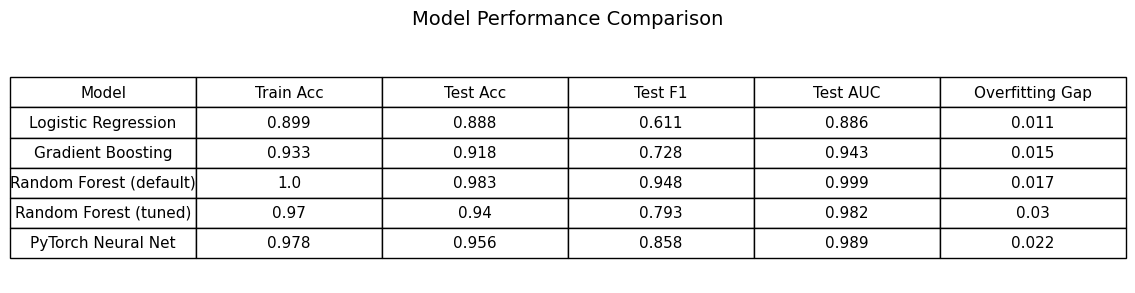

Comparison table saved as CSV and PNG!


In [14]:
# As CSV (easy to import later)
comparison.to_csv('models/model_comparison.csv', index=False)

# As an image for your README
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 3))
ax.axis('off')
table = ax.table(
    cellText=comparison.values,
    colLabels=comparison.columns,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)
plt.title('Model Performance Comparison', fontsize=14, pad=20)
plt.savefig('plots/model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

print("Comparison table saved as CSV and PNG!")